In [ ]:
import pandas as pd ## reading dataframe
import numpy as np ##  mathematical operation
# Preprocessing libraries
from sklearn.preprocessing import LabelEncoder, MinMaxScaler  # For encoding categorical variables and feature scaling
# Visualization libraries
import plotly.express as px  # To create interactive plots
import plotly.graph_objects as go  # For more customized interactive visualizations
import seaborn as sns  # For statistical data visualization
import matplotlib.pyplot as plt  # For basic plotting
# Data balancing library
from sklearn.utils import resample  # To balance the dataset using oversampling or undersampling
# Model selection and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV  # For data splitting and hyperparameter tuning
# Machine learning models
from sklearn.linear_model import LogisticRegression  # Logistic Regression model for classification
from sklearn.neighbors import KNeighborsClassifier  # K-Nearest Neighbors classifier
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier  # Ensemble models
# Evaluation metrics
from sklearn import metrics  # For accuracy, precision, recall, and other metrics
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score  # Detailed evaluation reports
# Deep learning libraries (TensorFlow/Keras)
import tensorflow as tf  # Deep learning framework
from tensorflow.keras.models import Sequential  # For building sequential neural networks
from tensorflow.keras.layers import Dense, Dropout  # Dense layers and dropout for regularization
import warnings  # Warnings module is used to manage warnings in the code.
warnings.filterwarnings("ignore")  # This line suppresses warnings to avoid clutter in the output.

In [ ]:
df = pd.read_csv('/content/Heart Disease.csv')
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12483,No,43.58,Yes,No,No,0,0,Yes,Female,80 or older,White,No,Yes,Good,7,No,No,No
12484,No,23.17,Yes,No,No,0,0,No,Male,70-74,White,Yes,Yes,Very good,7,No,No,Yes
12485,Yes,23.56,No,No,No,20,0,Yes,Female,80 or older,White,No,No,Fair,10,No,No,Yes
12486,No,22.89,No,No,No,0,1,No,Female,55-59,Black,Yes,Yes,Excellent,8,No,No,No


In [ ]:
# 1. Dataset Overview
print("\nDataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nData Types:\n", df.dtypes)
# 2. Check for Missing Values
print("\nMissing Values per Column:\n", df.isnull().sum())
# 3. Descriptive Statistics
print("\nDescriptive Statistics (Numerical):\n", df.describe())
print("\nDescriptive Statistics (Categorical):\n", df.describe(include='object'))


Dataset Shape: (12488, 18)

Column Names:
 Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

Data Types:
 HeartDisease         object
BMI                 float64
Smoking              object
AlcoholDrinking      object
Stroke               object
PhysicalHealth        int64
MentalHealth          int64
DiffWalking          object
Sex                  object
AgeCategory          object
Race                 object
Diabetic             object
PhysicalActivity     object
GenHealth            object
SleepTime             int64
Asthma               object
KidneyDisease        object
SkinCancer           object
dtype: object

Missing Values per Column:
 HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke         

In [ ]:
# Bar Plot 1
fig1 = px.bar(df, x='AgeCategory', y='BMI', title='BMI by Age Category', color='AgeCategory')
fig1.show()


In [ ]:
# Bar Plot 2
fig2 = px.bar(df, x='GenHealth', y='SleepTime', title='Sleep Time by General Health', color='GenHealth')
fig2.show()

In [ ]:
# Pie Chart
fig3 = px.pie(df, names='HeartDisease', title='Heart Disease Distribution')
fig3.show()

In [ ]:
# Scatter Plot 1
fig4 = px.scatter(df, x='BMI', y='PhysicalHealth', color='HeartDisease', title='BMI vs Physical Health')
fig4.show()

In [ ]:
# Scatter Plot 2
fig5 = px.scatter(df, x='SleepTime', y='MentalHealth', color='HeartDisease', title='Sleep Time vs Mental Health')
fig5.show()


In [ ]:
# Histogram
fig6 = px.histogram(df, x='BMI', title='BMI Distribution')
fig6.show()

In [ ]:
# Line Plot
fig7 = px.line(df.groupby('AgeCategory')['BMI'].mean().reset_index(), x='AgeCategory', y='BMI', title='Average BMI by Age Category')
fig7.show()


In [ ]:
# Box Plot
fig8 = px.box(df, x='HeartDisease', y='SleepTime', title='Sleep Time by Heart Disease')
fig8.show()


In [ ]:
# Violin Plot
fig9 = px.violin(df, y='BMI', x='GenHealth', color='HeartDisease', title='BMI Distribution by General Health')
fig9.show()

In [ ]:
# 5. Encoding Categorical Variables (Label Encoding)
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()
# Select numerical columns for MinMax scaling
num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
# Apply MinMax scaling to numerical columns
df[num_cols] = scaler.fit_transform(df[num_cols])

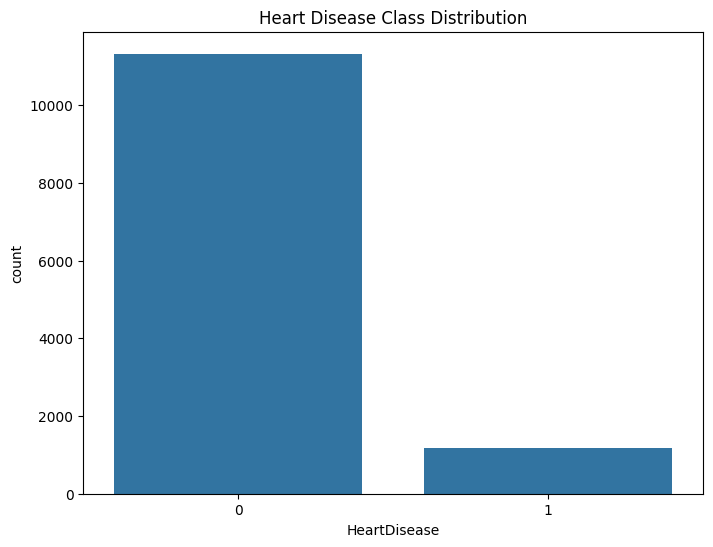

In [ ]:
# 8. Target Variable Balance Check
plt.figure(figsize=(8, 6))
sns.countplot(x='HeartDisease', data=df)
plt.title('Heart Disease Class Distribution')
plt.show()


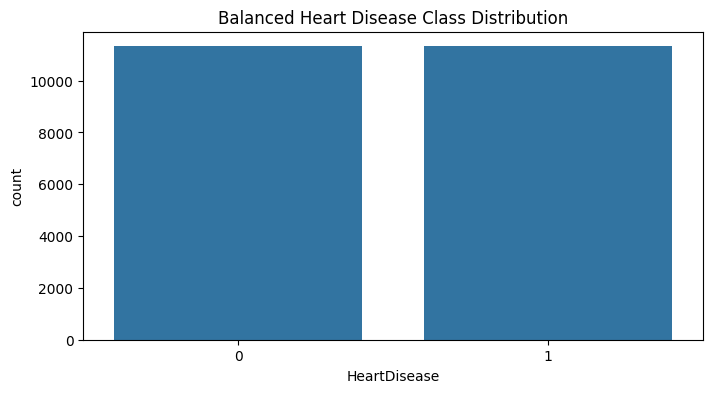

In [ ]:
# Balance the Dataset
# Separate majority and minority classes
df_majority = df[df['HeartDisease'] == 0]
df_minority = df[df['HeartDisease'] == 1]

# Upsample minority class
df_minority_upsampled = resample(df_minority,
                                 replace=True,    # sample with replacement
                                 n_samples=len(df_majority), # to match majority class
                                 random_state=42)

# Combine majority class with upsampled minority class
df = pd.concat([df_majority, df_minority_upsampled])

# Display new class distribution
plt.figure(figsize=(8,4))
sns.countplot(x='HeartDisease', data=df)
plt.title('Balanced Heart Disease Class Distribution')
plt.show()

In [ ]:
# Split the dataset into features and target variable
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train different machine learning models
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

params = {
    'Logistic Regression': {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    'KNN': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
}


Training Logistic Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score for Logistic Regression: 74.38%

Accuracy of Logistic Regression on test data: 0.73
Confusion Matrix:
 [[1686  607]
 [ 603 1634]]
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      2293
           1       0.73      0.73      0.73      2237

    accuracy                           0.73      4530
   macro avg       0.73      0.73      0.73      4530
weighted avg       0.73      0.73      0.73      4530

Cohen's Kappa Statistic for Logistic Regression: 0.47


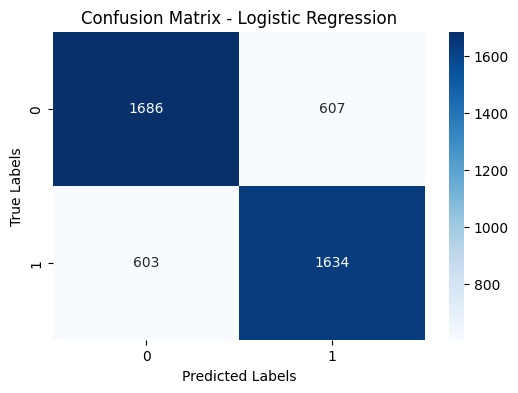


Training KNN...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters for KNN: {'n_neighbors': 3, 'weights': 'distance'}
Best cross-validation score for KNN: 92.48%

Accuracy of KNN on test data: 0.93
Confusion Matrix:
 [[1974  319]
 [   0 2237]]
              precision    recall  f1-score   support

           0       1.00      0.86      0.93      2293
           1       0.88      1.00      0.93      2237

    accuracy                           0.93      4530
   macro avg       0.94      0.93      0.93      4530
weighted avg       0.94      0.93      0.93      4530

Cohen's Kappa Statistic for KNN: 0.86


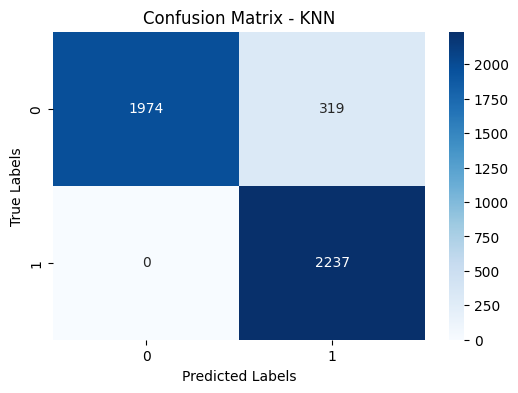


Training Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best cross-validation score for Gradient Boosting: 86.91%

Accuracy of Gradient Boosting on test data: 0.88
Confusion Matrix:
 [[1910  383]
 [ 176 2061]]
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      2293
           1       0.84      0.92      0.88      2237

    accuracy                           0.88      4530
   macro avg       0.88      0.88      0.88      4530
weighted avg       0.88      0.88      0.88      4530

Cohen's Kappa Statistic for Gradient Boosting: 0.75


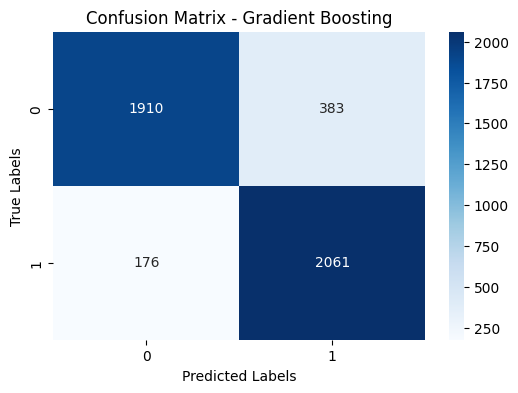

In [ ]:
best_estimators = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, params[model_name], cv=5, n_jobs=-1, verbose=1, scoring="accuracy")
    grid_search.fit(X_train, y_train)
    best_estimators[model_name] = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best cross-validation score for {model_name}: {grid_search.best_score_ * 100:.2f}%")

    # Predictions
    y_pred = grid_search.best_estimator_.predict(X_test)
    print(f"\nAccuracy of {model_name} on test data: {metrics.accuracy_score(y_test, y_pred):.2f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"Cohen's Kappa Statistic for {model_name}: {cohen_kappa_score(y_test, y_pred):.2f}")

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()


Accuracy of Hybrid Voting Classifier on test data: 0.8713024282560706
Confusion Matrix:
 [[1886  407]
 [ 176 2061]]
              precision    recall  f1-score   support

           0       0.91      0.82      0.87      2293
           1       0.84      0.92      0.88      2237

    accuracy                           0.87      4530
   macro avg       0.87      0.87      0.87      4530
weighted avg       0.88      0.87      0.87      4530

Cohen's Kappa Statistic for Hybrid Model: 0.742889720203376


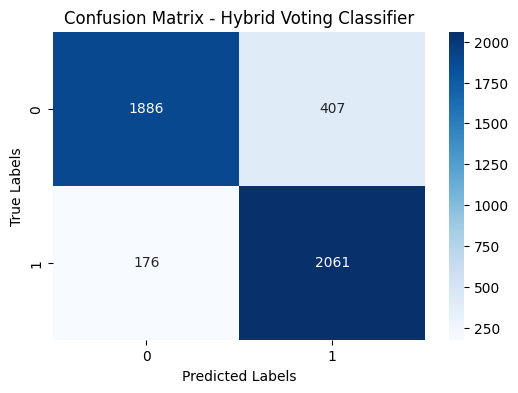

In [ ]:
# Hybrid Model using Voting Classifier
voting_clf = VotingClassifier(estimators=[
    ('lr', best_estimators['Logistic Regression']),
    ('knn', best_estimators['KNN']),
    ('gb', best_estimators['Gradient Boosting'])
], voting='hard')

voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)

print("\nAccuracy of Hybrid Voting Classifier on test data:", metrics.accuracy_score(y_test, y_pred_voting))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_voting))
print(classification_report(y_test, y_pred_voting))
print("Cohen's Kappa Statistic for Hybrid Model:", cohen_kappa_score(y_test, y_pred_voting))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_voting), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Hybrid Voting Classifier')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


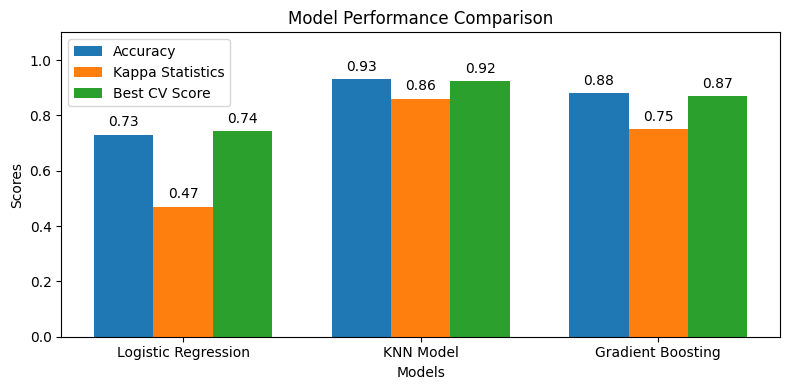

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Logistic Regression', 'KNN Model', 'Gradient Boosting']

# Performance metrics
accuracy = [0.73, 0.93, 0.88]
kappa = [0.47, 0.86, 0.75]
cv_score = [74.3, 92.4, 86.9]

# Convert CV scores to 0-1 range for consistent plotting (optional)
cv_score_normalized = [score / 100 for score in cv_score]

# Set position of bar on X axis
x = np.arange(len(models))
width = 0.25  # Width of the bars

# Create subplots
fig, ax = plt.subplots(figsize=(8,4))

# Plot bars
bars1 = ax.bar(x - width, accuracy, width, label='Accuracy')
bars2 = ax.bar(x, kappa, width, label='Kappa Statistics')
bars3 = ax.bar(x + width, cv_score_normalized, width, label='Best CV Score')

# Labels and formatting
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()

# Annotate each bar with its value
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

# Show plot
plt.tight_layout()
plt.show()
